### Attitude Control Error modeling

The telescope of JASMINE is designed to achieve almost diffraction-limited point-spread functions (PSFs) over the entire field of view. Thus, the actual PSFs will be determined by the attitude control errors (ACEs) of the satellite. Accurate modeling of the ACEs is essential to evaluate the accuracy of positional measurements in the JASMINE mission. This notebook demonstrates a tool to simulate the ACE in `jasmine_toolkit`.

In [1]:
import matplotlib
import matplotlib.pyplot as plt

import jasmine_toolkit.optics.jitter as jitter
import numpy as np
import scipy.fft as fft

matplotlib.rcParams['legend.frameon'] = False

A sophisticated PSF simulation is provided in [`jasine-imagesim`][1]. There, the ACE is modelled in a frequency domain. We assumed a power spectrum density function of the ACE. The phases are randomly and independently sampled form a uniform distribution. The trajectory of the ACE is obtained by integrating over the frequency.

The cell below illustrates the power spectrum assumed in `imagesim`, which is normalized to unity at lower frequency.

[1]: https://github.com/JASMINE-Mission/jasmine-imagesim

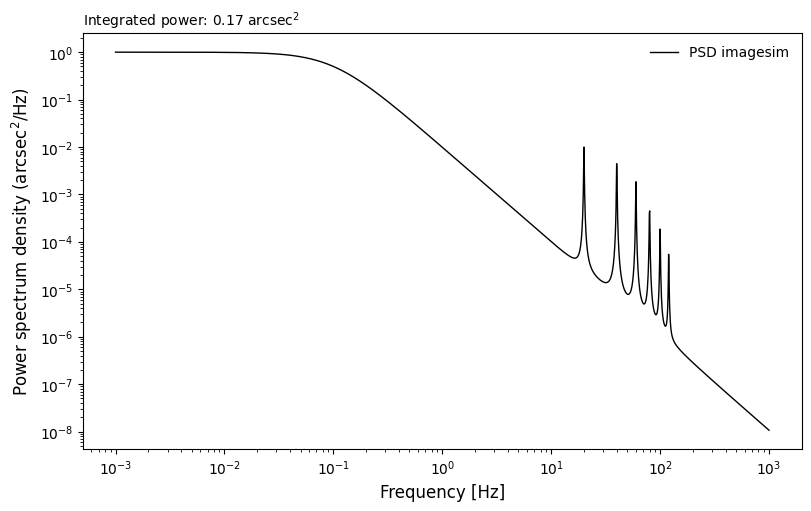

In [2]:
fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')

freq = np.logspace(-3, 3, 2000)
psd = jitter.PSD_imagesim(freq)
power = np.trapezoid(psd, freq)

ax.plot(
  freq, psd,
  color='black', lw=1, label='PSD imagesim')

ax.set_xlabel('Frequency [Hz]', fontsize=12)
ax.set_ylabel('Power spectrum density (arcsec$^2$/Hz)', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=10)
ax.set_title(
  f'Integrated power: {power:.2f} arcsec$^2$', fontsize=10, loc='left')

plt.show()

`jasmine_toolkit` provide a tool to simulate the ACE using a time-domain modeling. A time series of jitter motion can be generated by ARMA or ARIMA models. Here, we illustrate an ARIMA model that is designed to simulate the power spectrum in `imagesim`.

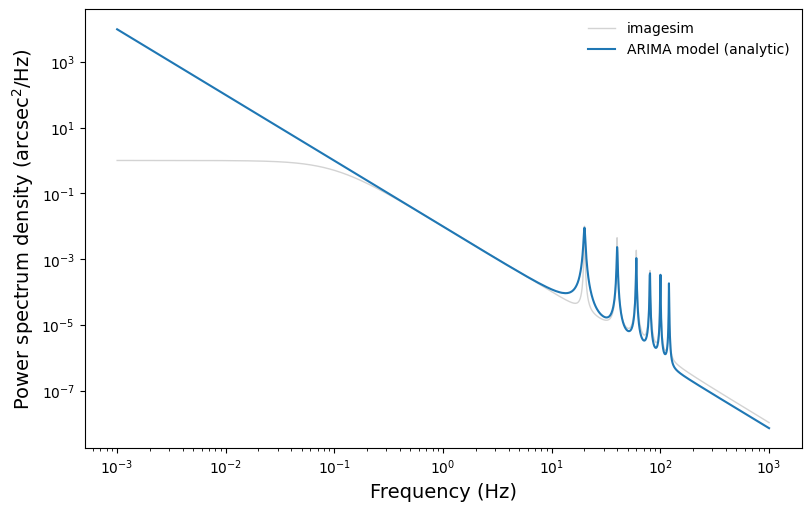

In [3]:
fig, ax = plt.subplots(
  figsize=(8, 5), layout='constrained')

dt = 5e-4
freq = np.logspace(-3, 3, 2000)

model = jitter.ARIMAModel(
  *jitter.coeff_imagesim(), 3e-4, sampling_interval=dt)
psd = model.psd(freq)

ax.plot(
  freq, jitter.PSD_imagesim(freq), color='lightgray', lw=1,
  label='imagesim')
ax.plot(
  freq, psd,
  label='ARIMA model (analytic)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=10)

ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel('Power spectrum density (arcsec$^2$/Hz)', fontsize=14)

plt.show()

A trajectory of jitter motion is generated by the model.

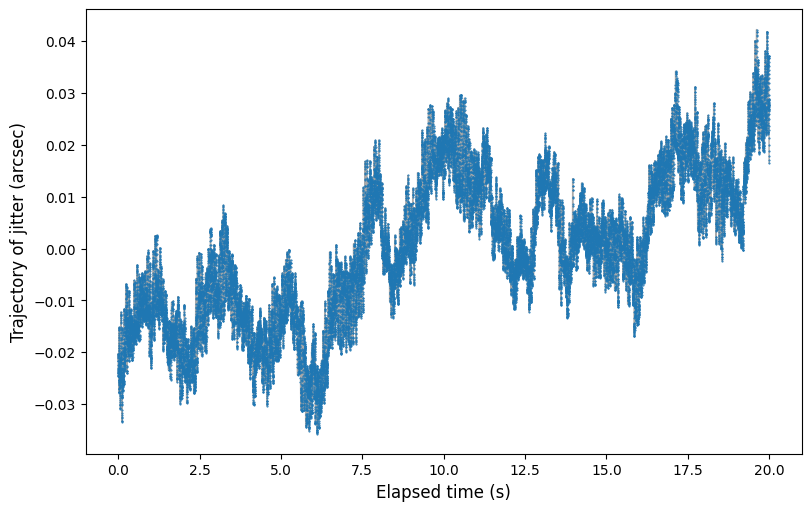

In [4]:
fig, ax = plt.subplots(
  figsize=(8, 5), layout='constrained')

N = 40000
sample = model.generate(N, seed=42)

ax.plot(
  dt * np.arange(N), sample, color='darkgray', lw=1, zorder=-1)
ax.scatter(
  dt * np.arange(N), sample, s=1, marker='.')

ax.set_xlabel('Elapsed time (s)', fontsize=12)
ax.set_ylabel('Trajectory of jitter (arcsec)', fontsize=12)

plt.show()

The power spectrum of the generated sequence is illustrated below, suggesting that the model well reproduces the power spectrum in `imagesim`.

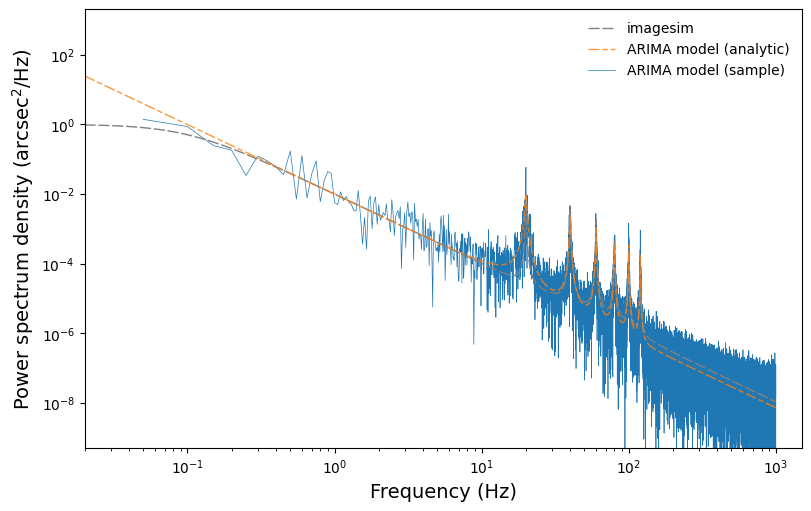

In [5]:
fig, ax = plt.subplots(
  figsize=(8, 5), layout='constrained')

ax.plot(
  freq, jitter.PSD_imagesim(freq),
  dashes=(8, 2), color='gray', lw=1,
  label='imagesim')
ax.plot(
  freq, psd, dashes=(8, 2, 4, 2),
  lw=1, alpha=0.8, color='C1',
  label='ARIMA model (analytic)')
ax.plot(
  np.arange(1, N//2) / N / dt,
  fft.fftshift(np.abs(fft.fft(sample)))[N//2 + 1:]**2 / N,
  zorder=-1, lw=0.5, color='C0',
  label='ARIMA model (sample)')

ax.set_xlim([2e-2, 1.5e3])
ax.set_ylim([5e-10, 2e3])
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=10)

ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel('Power spectrum density (arcsec$^2$/Hz)', fontsize=14)

plt.show()

`jasmine_imagesim` also provides another model, `ACEModel`, which is based on an ARIMA ($j$, $k$, 1) model but monitors the current state and controls itself around zero. The cell below illustrates the trajectories generated in three different specifications.

|Parameter|Value|Description|
|:---|:---|:---|
|`sigma`           | $0.5$        | Scaling parameter in arcsec |
|`samling_interval`| $5 \times 10^{-4}$ | Sampling interval of the sequence in second |
|`latency`         | $100$        | Latency of the feedback (50 ms) |
|`gain`            | variable     | Feedback gain|

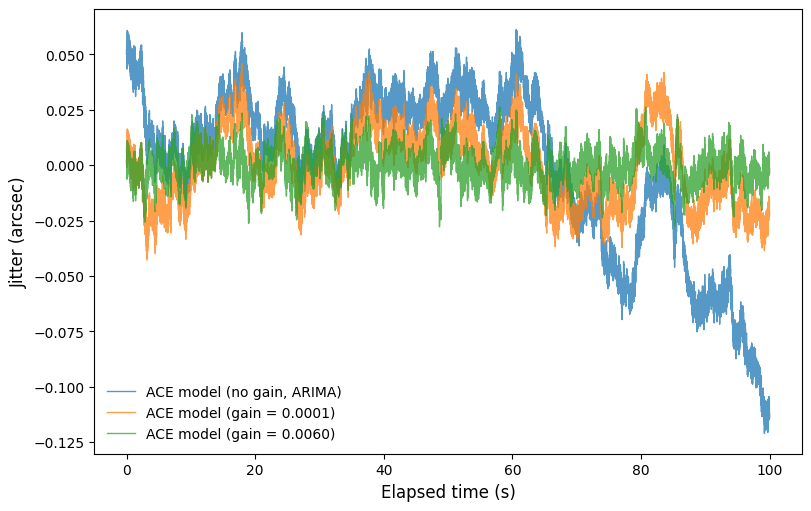

In [6]:
fig, ax = plt.subplots(
  figsize=(8, 5), layout='constrained')

N = 200000

def get_model(gain):
  return jitter.ACEModel(
    *jitter.coeff_imagesim(),
    sigma=0.5,
    sampling_interval=dt,
    latency=100,
    gain=gain)

model = get_model(0)
sample0 = model.generate(N, seed=10)

ax.plot(
  dt * np.arange(N), sample0, lw=1, alpha=0.75,
  label='ACE model (no gain, ARIMA)')

model = get_model(1e-4)
sample1 = model.generate(N, seed=10)

ax.plot(
  dt * np.arange(N), sample1, lw=1, alpha=0.75,
  label=r'ACE model (gain = 0.0001)')

model = get_model(6e-3)
sample2 = model.generate(N, seed=10)

ax.plot(
  dt * np.arange(N), sample2, lw=1, alpha=0.75,
  label=r'ACE model (gain = 0.0060)')

ax.set_xlabel('Elapsed time (s)', fontsize=12)
ax.set_ylabel('Jitter (arcsec)', fontsize=12)
ax.legend(loc='lower left', fontsize=10)

plt.show()

The power spectra of the generated trajectories are illustrated below. The power at lower frequencies is suppressed when the feedback gain is increased.

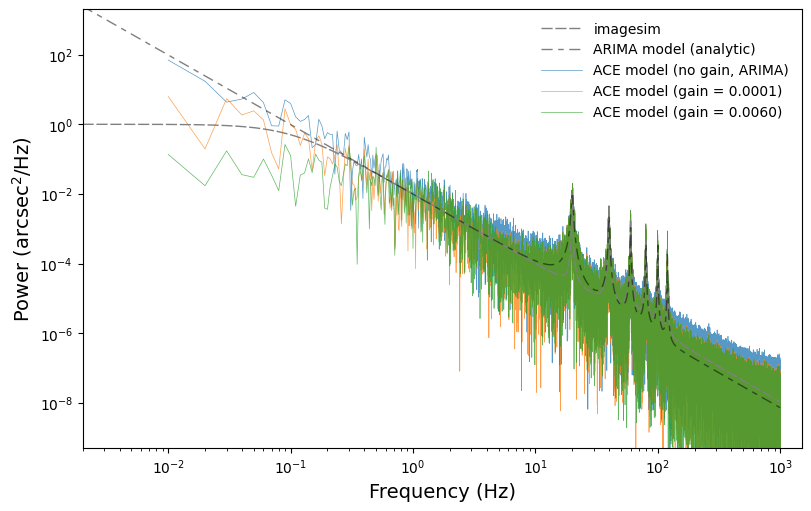

In [7]:
fig, ax = plt.subplots(
  figsize=(8, 5), layout='constrained')

ax.plot(
  freq, jitter.PSD_imagesim(freq),
  dashes=(8, 2), color='gray', lw=1,
  label='imagesim')
ax.plot(
  freq, psd, dashes=(8, 4, 4, 4),
  lw=1, alpha=0.5, color='black',
  label='ARIMA model (analytic)')

ax.plot(
  np.arange(1, N//2) / N / dt,
  fft.fftshift(np.abs(fft.fft(sample0)))[N//2 + 1:]**2 / N,
  zorder=-1, lw=0.5, color='C0', alpha=0.75,
  label='ACE model (no gain, ARIMA)')
ax.plot(
  np.arange(1, N//2) / N / dt,
  fft.fftshift(np.abs(fft.fft(sample1)))[N//2 + 1:]**2 / N,
  zorder=-1, lw=0.5, color='C1', alpha=0.75,
  label='ACE model (gain = 0.0001)')
ax.plot(
  np.arange(1, N//2) / N / dt,
  fft.fftshift(np.abs(fft.fft(sample2)))[N//2 + 1:]**2 / N,
  zorder=-1, lw=0.5, color='C2', alpha=0.75,
  label='ACE model (gain = 0.0060)')

ax.set_xlim([2e-3, 1.5e3])
ax.set_ylim([5e-10, 2e3])
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=10, handlelength=3)

ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel('Power (arcsec$^2$/Hz)', fontsize=14)

plt.show()

We can simulate a trajectory on a focal plane when we generate sequences with different seeds.

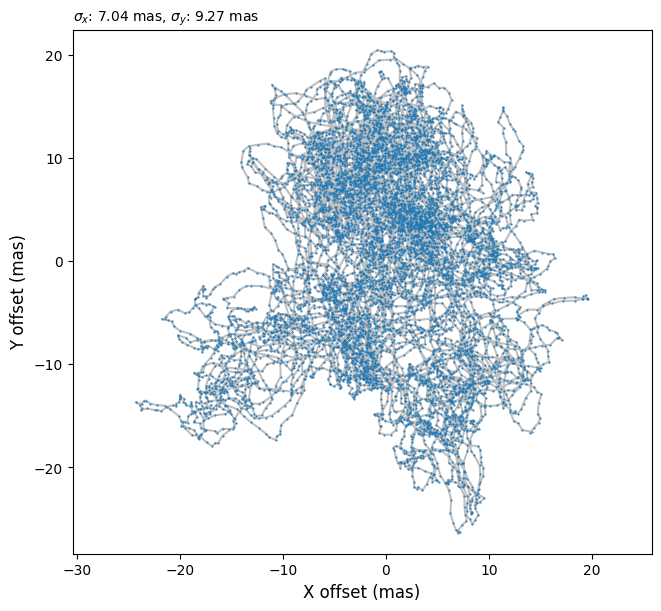

In [12]:
x = model.generate(10000, seed=2000) * 1e3
y = model.generate(10000, seed=2031) * 1e3

fig, ax = plt.subplots(
  figsize=(6.5, 6), layout='constrained')

ax.plot(x, y, alpha=0.5, color='gray', zorder=-1)
ax.scatter(x, y, s=1, marker='.')

ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel('X offset (mas)', fontsize=12)
ax.set_ylabel('Y offset (mas)', fontsize=12)
ax.set_title(
  f'$\sigma_x$: {x.std():.2f} mas, $\sigma_y$: {y.std():.2f} mas',
  loc='left', fontsize=10)

plt.show()